In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [5]:
# Load the data set
df = pd.read_csv ('student_performance.csv')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            50000 non-null  str    
 1   school_id             50000 non-null  str    
 2   lga                   50000 non-null  str    
 3   gender                50000 non-null  str    
 4   age                   50000 non-null  int64  
 5   course                50000 non-null  str    
 6   term                  50000 non-null  str    
 7   academic_year         50000 non-null  str    
 8   attendance_pct        50000 non-null  float64
 9   ca_score              50000 non-null  float64
 10  exam_score            50000 non-null  float64
 11  total_score           50000 non-null  float64
 12  grade                 50000 non-null  str    
 13  passed                50000 non-null  str    
 14  study_hours_per_week  50000 non-null  float64
 15  parent_education      40071 no

In [8]:
df.head()

,student_id,school_id,lga,gender,age,course,term,academic_year,attendance_pct,ca_score,exam_score,total_score,grade,passed,study_hours_per_week,parent_education,school_type,internet_access
0,STU-400000,School_063,Surulere,Male,16,Government,Term 3,2022/2023,91.0,21.5,32.3,53.8,C,Yes,11.1,University,Private,No
1,STU-400001,School_045,Apapa,Male,17,Literature,Term 2,2021/2022,73.5,32.5,48.8,81.3,A,Yes,5.0,University,Public,Yes
2,STU-400002,School_008,Ojo,Male,19,Biology,Term 1,2023/2024,48.8,23.6,35.5,59.1,C,Yes,5.5,University,Public,No
3,STU-400003,School_012,Alimosho,Female,18,Mathematics,Term 2,2023/2024,61.7,25.6,38.4,64.0,B,Yes,4.5,Postgraduate,Private,Yes
4,STU-400004,School_003,Agege,Female,17,English,Term 2,2023/2024,49.1,17.9,26.9,44.8,F,No,23.1,Primary,Private,Yes


In [9]:
df.dtypes

student_id                  str
school_id                   str
lga                         str
gender                      str
age                       int64
course                      str
term                        str
academic_year               str
attendance_pct          float64
ca_score                float64
exam_score              float64
total_score             float64
grade                       str
passed                      str
study_hours_per_week    float64
parent_education            str
school_type                 str
internet_access             str
dtype: object

In [10]:
df.shape

(50000, 18)

In [11]:
# Inspect the data structure
print(f"Dataset shape:{df.shape[0]}rows,{df.shape[1]} columns")

Dataset shape:50000rows,18 columns


In [12]:
# Misiing values per column 
print(df.isnull().sum())

student_id                 0
school_id                  0
lga                        0
gender                     0
age                        0
course                     0
term                       0
academic_year              0
attendance_pct             0
ca_score                   0
exam_score                 0
total_score                0
grade                      0
passed                     0
study_hours_per_week       0
parent_education        9929
school_type                0
internet_access            0
dtype: int64


In [13]:
# Fill the missing values in Parent_education
df['parent_education']= df ['parent_education'].fillna('Unknown')

In [15]:
# Binary columns for failed and passed
df ['is_passed'] = df['passed'].apply(lambda x: 1 if x =='Yes' else 0)
df ['is_failed'] = df['passed'].apply(lambda x: 1 if x =='No' else 0)

In [19]:
# Global seaborn visualization theme
sns.set_theme(style="whitegrid")

In [28]:
# 128. Pass rate per subject
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the pass rate per subject (returns a pandas Series)
pass_rate_subject = (
    df.groupby("course")["passed"].apply(lambda x: (x == "Yes").mean()).sort_values()
)



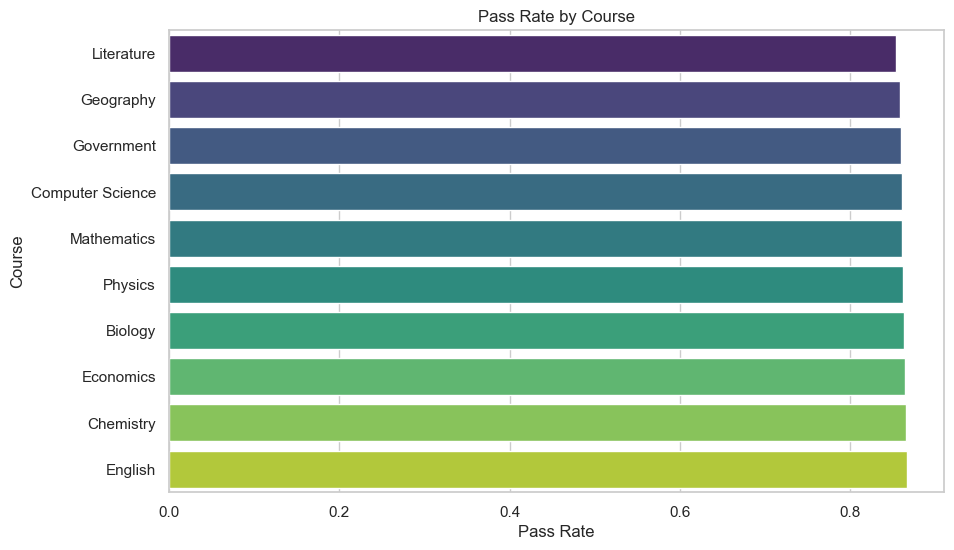

In [31]:
# 2. Plot safely using hue mapping to avoid the palette error
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    x=pass_rate_subject.values,
    y=pass_rate_subject.index,
    hue=pass_rate_subject.index,  # Maps colors to the courses
    palette="viridis",
    legend=False,  # Hides the redundant legend
    ax=ax,
)
# Optional styling for a cleaner look
ax.set_xlabel("Pass Rate")
ax.set_ylabel("Course")
ax.set_title("Pass Rate by Course")

plt.show()


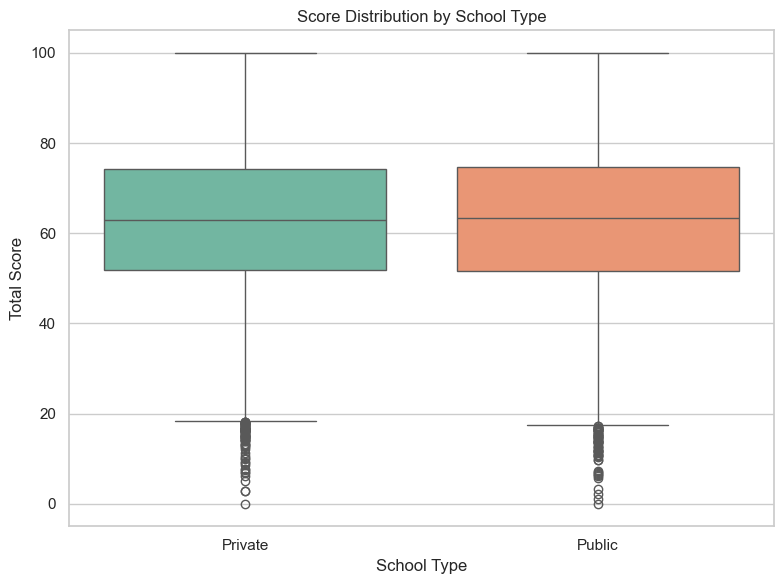

In [35]:
# 129. Box plot: Score distribution by school type (Public vs Private)
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 6))

# Fixed: Added hue="school_type" and legend=False to prevent the palette error
sns.boxplot(
    x="school_type",
    y="total_score",
    data=df,
    hue="school_type",
    legend=False,
    ax=ax,
    palette="Set2",
)

ax.set_title("Score Distribution by School Type")
ax.set_xlabel("School Type")
ax.set_ylabel("Total Score")
plt.tight_layout()
plt.show()



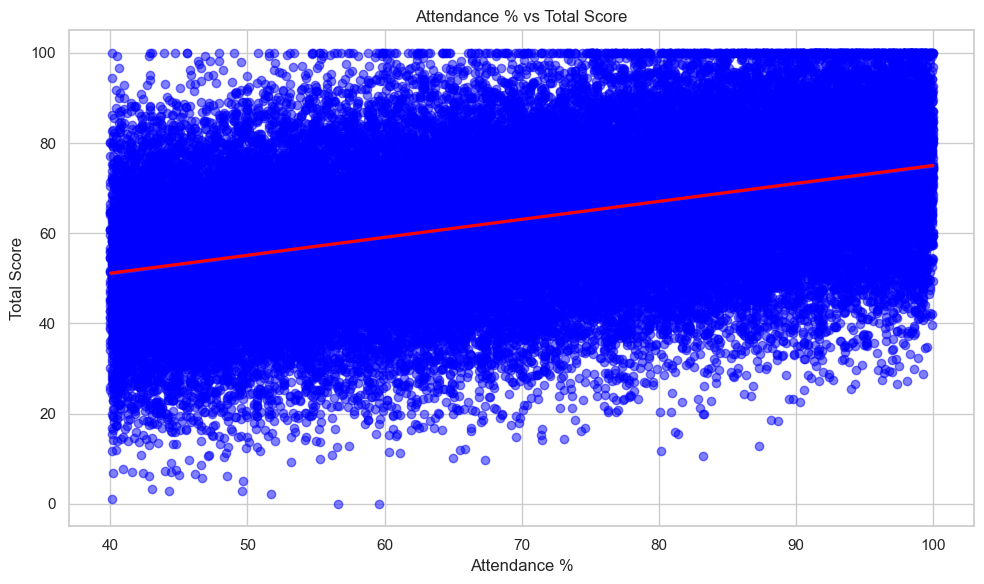

In [38]:
# 130. Scatter plot: Attendance % vs Total Score with a regression line
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 6))

# Fixed: Removed hidden non-breaking spaces from line continuations
sns.regplot(
    x="attendance_pct",
    y="total_score",
    data=df,
    ax=ax,
    scatter_kws={"alpha": 0.5, "color": "blue"},
    line_kws={"color": "red"},
)

ax.set_title("Attendance % vs Total Score")
ax.set_xlabel("Attendance %")
ax.set_ylabel("Total Score")
plt.tight_layout()
plt.show()

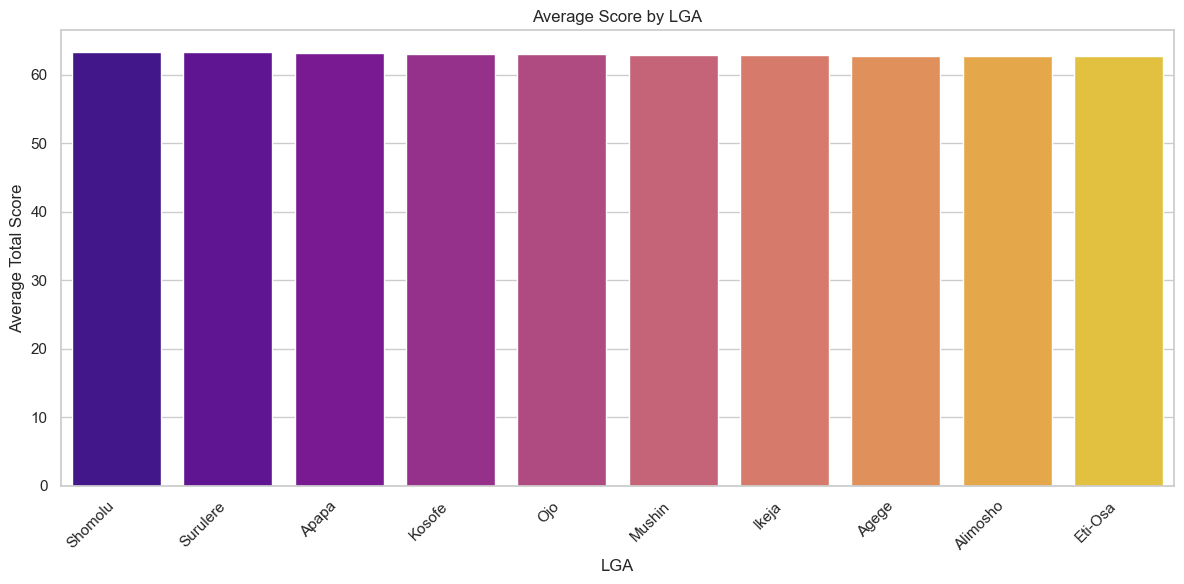

In [39]:
# 131. Bar chart: Average score by LGA
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

avg_score_lga = df.groupby("lga")["total_score"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))

# Fixed: Added hue mapping and disabled the redundant legend to fix the palette error
sns.barplot(
    x=avg_score_lga.index,
    y=avg_score_lga.values,
    hue=avg_score_lga.index,
    palette="plasma",
    legend=False,
    ax=ax,
)

ax.set_title("Average Score by LGA")
ax.set_xlabel("LGA")
ax.set_ylabel("Average Total Score")

# Fixed: Explicitly set the tick positions before changing the labels to avoid alignment bugs
ax.set_xticks(range(len(avg_score_lga)))
ax.set_xticklabels(avg_score_lga.index, rotation=45, ha="right")

plt.tight_layout()
plt.show()

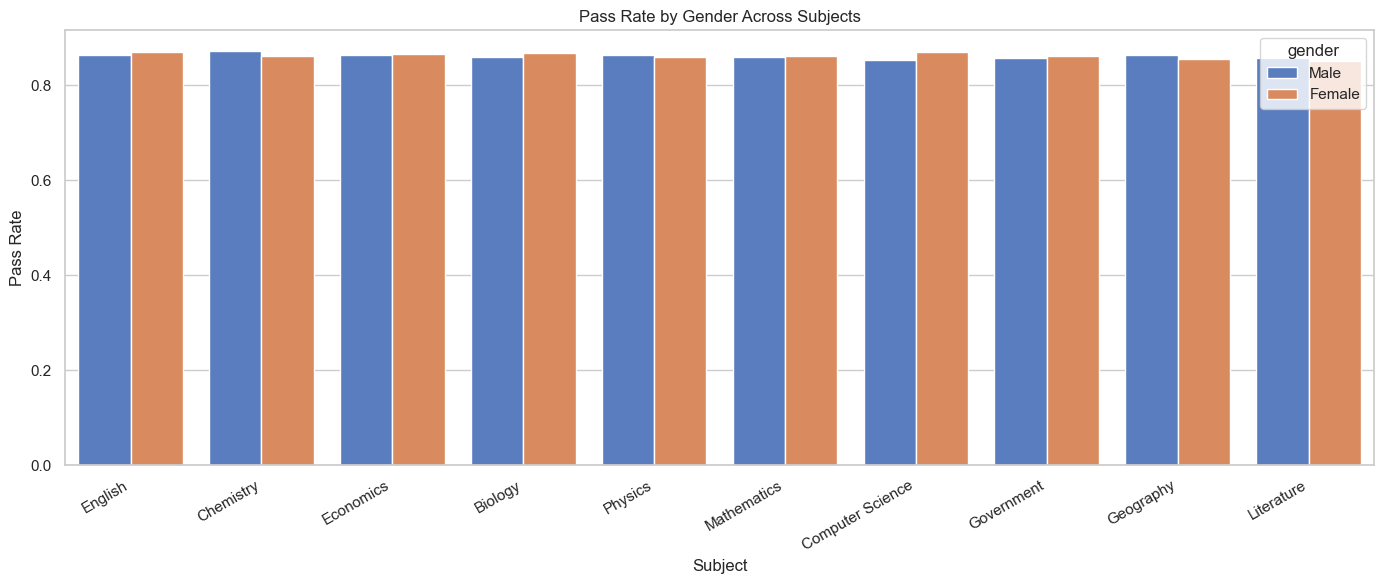

In [40]:
# 132. Grouped bar chart: Pass rate by gender across subjects
# =====================================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Note: Ensure 'is_passed' is numeric (1 for pass, 0 for fail) for .mean() to work
df_gender_subject = (
    df.groupby(["course", "gender"])["is_passed"].mean().reset_index()
)

# Fixed: Calculate overall order directly to avoid missing variable errors
overall_order = (
    df.groupby("course")["is_passed"].mean().sort_values(ascending=False).index
)

df_gender_subject["course"] = pd.Categorical(
    df_gender_subject["course"], categories=overall_order, ordered=True
)
df_gender_subject = df_gender_subject.sort_values("course")

fig, ax = plt.subplots(figsize=(14, 6))

# This works out of the box because 'hue' is already explicitly set here
sns.barplot(
    x="course",
    y="is_passed",
    hue="gender",
    data=df_gender_subject,
    ax=ax,
    palette="muted",
)

ax.set_title("Pass Rate by Gender Across Subjects")
ax.set_xlabel("Subject")
ax.set_ylabel("Pass Rate")

# Fixed: Explicitly set ticks before changing labels to prevent alignment bugs
ax.set_xticks(range(len(overall_order)))
ax.set_xticklabels(overall_order, rotation=30, ha="right")

plt.tight_layout()
plt.show()

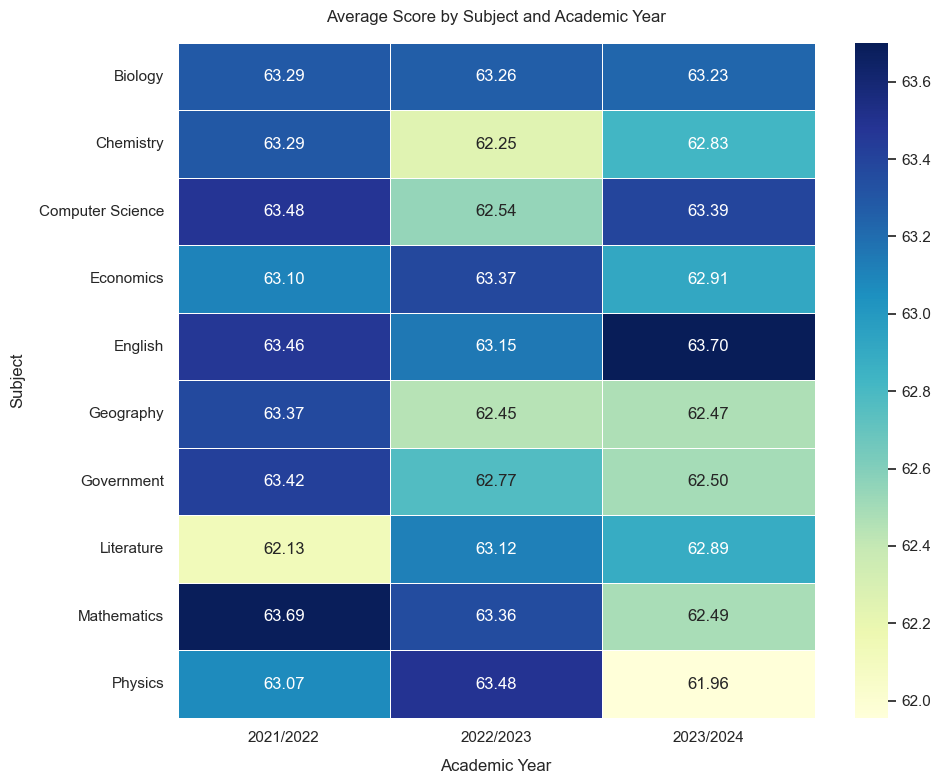

In [41]:
# 133. Heatmap: Average score by subject and academic year
# =====================================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Safety Check: Clean up any accidental leading/trailing spaces in categorical columns
df["course"] = df["course"].astype(str).str.strip()
df["academic_year"] = df["academic_year"].astype(str).str.strip()

# Create the pivot table
avg_score_subject_year = df.pivot_table(
    index="course", columns="academic_year", values="total_score", aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(10, 8))

# Generates the heatmap cleanly
sns.heatmap(
    avg_score_subject_year,
    annot=True,  # Displays the mean values inside each cell
    fmt=".2f",  # Rounds numbers to 2 decimal places
    cmap="YlGnBu",
    linewidths=0.5,  # Optional: Adds a subtle grid line between cells
    ax=ax,
)

ax.set_title("Average Score by Subject and Academic Year", pad=15)
ax.set_xlabel("Academic Year", labelpad=10)
ax.set_ylabel("Subject", labelpad=10)

# Optional safety: Ensure the y-axis labels are completely horizontal and visible
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

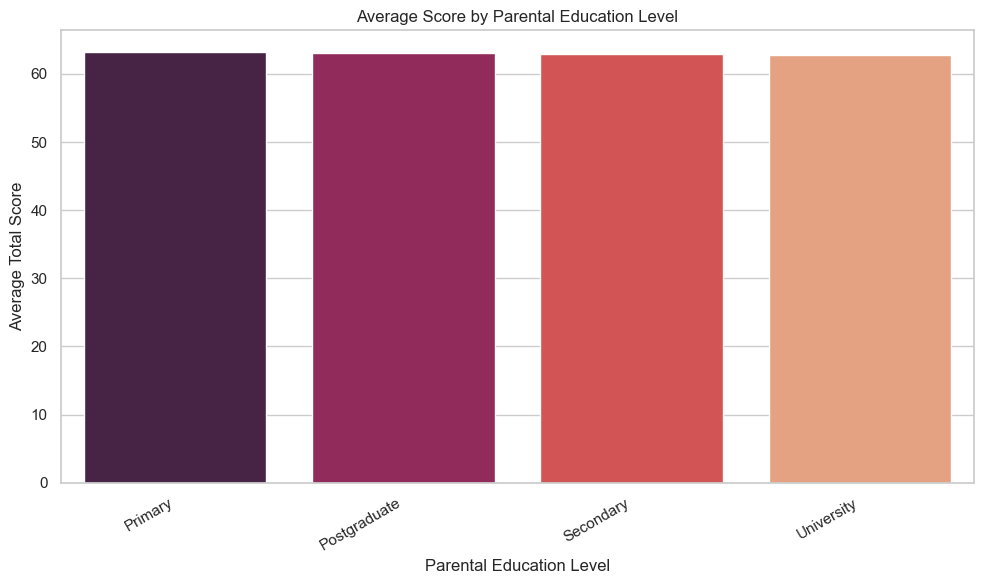

In [42]:
# 134. Bar chart: Score comparison by parental education level
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

avg_score_parent_edu = (
    df.groupby("parent_education")["total_score"].mean().sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 6))

# Fixed: Added hue mapping and disabled the redundant legend to fix the palette error
sns.barplot(
    x=avg_score_parent_edu.index,
    y=avg_score_parent_edu.values,
    hue=avg_score_parent_edu.index,
    palette="rocket",
    legend=False,
    ax=ax,
)

ax.set_title("Average Score by Parental Education Level")
ax.set_xlabel("Parental Education Level")
ax.set_ylabel("Average Total Score")

# Fixed: Set ticks explicitly and rotated the labels so long text doesn't overlap
ax.set_xticks(range(len(avg_score_parent_edu)))
ax.set_xticklabels(avg_score_parent_edu.index, rotation=30, ha="right")

plt.tight_layout()
plt.show()

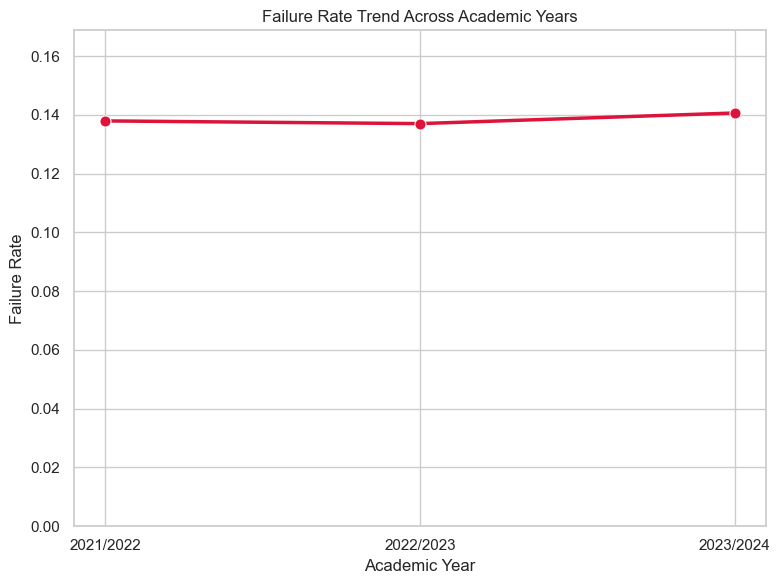

In [49]:
# 135. Line chart: Failure rate trend across the three academic years
# =====================================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Clean and normalize all column names in your dataframe
df.columns = df.columns.str.strip().str.lower()

# 2. DYNAMICALLY find your columns so the script never breaks
year_col = None
fail_col = None

# Scan for the academic year column
for col in df.columns:
    if "year" in col or "academic" in col:
        year_col = col
        break

# Scan for the failure or pass column
for col in df.columns:
    if "fail" in col or "pass" in col:
        fail_col = col
        break

# Fallback error handling with a helpful readout of what columns you actually have
if not year_col or not fail_col:
    raise KeyError(
        f"Could not automatically detect your columns! \n"
        f"Your dataset columns are: {list(df.columns)}\n"
        f"Please rename your target columns to include the words 'year' and 'fail' (or 'pass')."
    )

# 3. Vectorized conversion to handle boolean, numeric, or string ("Yes"/"No"/"Pass"/"Fail")
# If the column tracks 'passing' instead of 'failing', we will invert it mathematically
is_failed_numeric = None

# Clean up the target column series to evaluate it
series_clean = df[fail_col].astype(str).str.strip().str.lower()

if "pass" in fail_col:
    # If it's a pass column, failure is where pass is false/no
    is_failed_numeric = series_clean.isin(["no", "false", "0", "f"]).astype(int)
else:
    # If it's a fail column, failure is where fail is true/yes
    is_failed_numeric = series_clean.isin(["yes", "true", "1", "t"]).astype(int)

# Fallback: If it was already purely numeric (0 and 1) and didn't match text strings
if is_failed_numeric.sum() == 0 and pd.api.types.is_numeric_dtype(df[fail_col]):
    if "pass" in fail_col:
        is_failed_numeric = 1 - df[fail_col].astype(int)
    else:
        is_failed_numeric = df[fail_col].astype(int)


# 4. Group and compute the mean using our dynamically discovered columns
failure_rate_year = is_failed_numeric.groupby(df[year_col]).mean()

# 5. Build and save the plot
fig, ax = plt.subplots(figsize=(8, 6))

sns.lineplot(
    x=failure_rate_year.index.astype(str),
    y=failure_rate_year.values,
    marker="o",
    markersize=8,
    linewidth=2.5,
    color="crimson",
    ax=ax,
)

ax.set_title("Failure Rate Trend Across Academic Years")
ax.set_xlabel("Academic Year")
ax.set_ylabel("Failure Rate")

# Safe y-axis limit assignment to prevent crash if max value is 0
max_val = max(failure_rate_year.values) if len(failure_rate_year) > 0 else 0
ax.set_ylim(0, max_val * 1.2 if max_val > 0 else 0.1)

plt.tight_layout()
plt.show ()

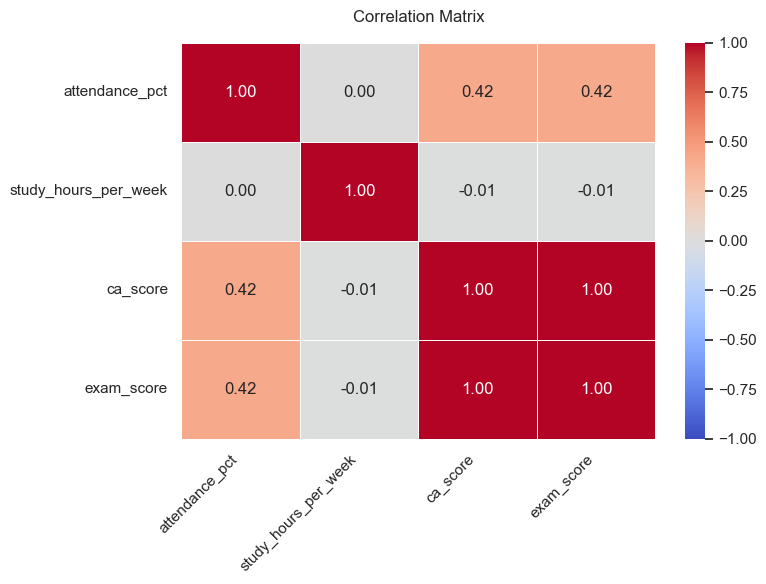

In [50]:
# 136. Correlation matrix: Attendance, study hours, CA score, exam score
# =====================================================================
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Standardize columns & safely strip text like '%' if present
cols_to_corr = ["attendance_pct", "study_hours_per_week", "ca_score", "exam_score"]

# Ensure columns exist, stripping trailing whitespace from dataframe columns first
df.columns = df.columns.str.strip()
existing_cols = [col for col in cols_to_corr if col in df.columns]

if len(existing_cols) < 2:
    raise KeyError(
        f"Need at least 2 matching numeric columns. Found: {existing_cols}. "
        f"Available columns are: {list(df.columns)}"
    )

# 2. Force conversion to numeric data types, cleaning string artifacts like '%'
for col in existing_cols:
    if df[col].dtype == "object":
        df[col] = (
            df[col].astype(str).str.replace("%", "", regex=False).str.strip()
        )
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 3. Calculate correlation matrix explicitly on numeric data
corr_matrix = df[existing_cols].corr()

# 4. Build and save the heatmap cleanly
fig, ax = plt.subplots(figsize=(8, 6))

# Fixed: fmt is set to ".2f" so values fit comfortably inside heatmap tiles
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    ax=ax,
)

ax.set_title("Correlation Matrix", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()